In [43]:
import pandas as pd
import numpy as np 
df = pd.read_csv("../data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [44]:
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [45]:
cols_to_drop = missing_percentage[missing_percentage>50].index
df = df.drop(columns=cols_to_drop)
print("Dropped Columns:")
print(cols_to_drop)
print("\nRemianing Columns:", df.shape[1])

Dropped Columns:
Index(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'], dtype='str')

Remianing Columns: 76


In [46]:
df.isnull().sum().sort_values(ascending=False).head(20)

FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageQual       81
GarageFinish     81
GarageType       81
GarageCond       81
BsmtFinType2     38
BsmtExposure     38
BsmtQual         37
BsmtCond         37
BsmtFinType1     37
MasVnrArea        8
Electrical        1
LotConfig         0
LandSlope         0
Neighborhood      0
LotShape          0
Street            0
LotArea           0
dtype: int64

In [47]:
#Get all numerical columns
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
#Filling misssing values with median 
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [48]:
# Get all categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

# Fill missing values with "Missing"
for col in categorical_cols:
    df[col] = df[col].fillna("Missing")

C:\Users\yashasvi\AppData\Local\Temp\ipykernel_19628\1068303257.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [49]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
# Age of the house when it was sold
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# Years since last remodeling
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

# Total Bathrooms
df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

# Total Square Footage
df["TotalSF"] = (
    df["TotalBsmtSF"]
    + df["1stFlrSF"]
    + df["2ndFlrSF"]
)

# Total Porch Area
df["TotalPorchSF"] = (
    df["OpenPorchSF"]
    + df["EnclosedPorch"]
    + df["3SsnPorch"]
    + df["ScreenPorch"]
)

In [50]:
df = pd.get_dummies(df, drop_first=True)

In [51]:
df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [52]:
print(df.shape)

(1460, 246)


In [53]:
X = df.drop("SalePrice",axis=1)
y = np.log1p(df["SalePrice"])

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](245,)","[-0. ,-0. ,-0. ,..., 0.03, 0.05, 0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](245,)","['Id','MSSubClass','LotFrontage',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.17
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,245
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(228)


In [57]:
y_pred_log = model.predict(X_test)

In [58]:
# Convert predictions back
y_pred = np.expm1(y_pred_log)

# Convert actual values back
y_test_actual = np.expm1(y_test)

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 16317.12
RMSE : 24661.04
R²   : 0.9207


In [61]:
import os

print(os.getcwd())

d:\SCT_ML_1\notebooks


In [62]:
import joblib

joblib.dump(model, "../model/house_price_model.pkl")
joblib.dump(X.columns.tolist(), "../model/model_columns.pkl")

print("✅ Final model saved successfully!")

✅ Final model saved successfully!


# Experiments

The following sections contain additional experiments (outlier removal, feature selection, etc.). After evaluation, the baseline preprocessing pipeline with Linear Regression (R² = 0.9207) was selected as the final model because it achieved the best overall performance for this project.

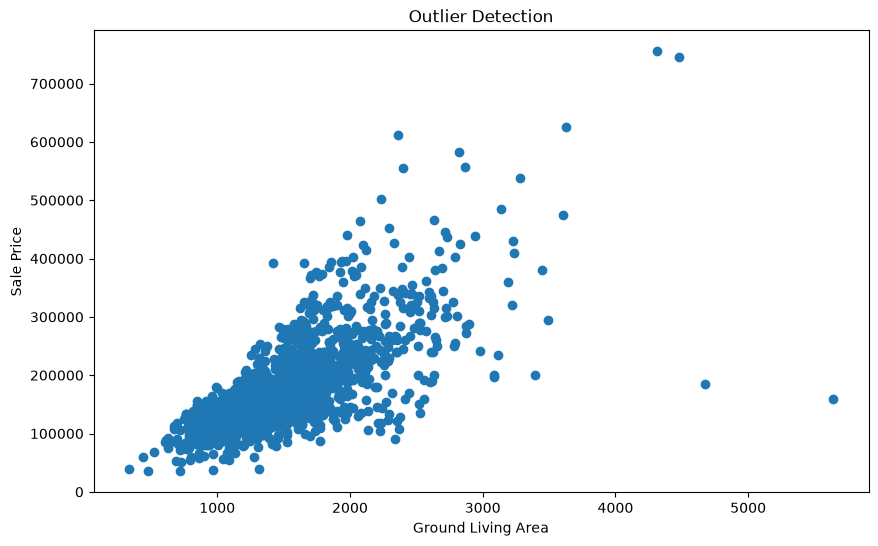

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")

plt.title("Outlier Detection")

plt.show()

In [29]:
df = df.drop(
    df[
        (df["GrLivArea"] > 4000) &
        (df["SalePrice"] < 300000)
    ].index
)

In [30]:
print(df.shape)

(1458, 251)


In [31]:
df = pd.get_dummies(df, drop_first=True)

In [32]:
X = df.drop("SalePrice",axis=1)
y = np.log1p(df["SalePrice"])

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](250,)","[-0. , 0. , 0. ,..., 0.02, 0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](250,)","['Id','MSSubClass','LotFrontage',...,'TotalBathrooms','TotalSF', 'TotalPorchSF']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.39
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,250
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(227)


In [35]:
y_pred_log = model.predict(X_test)

In [36]:
# Convert predictions back
y_pred = np.expm1(y_pred_log)

# Convert actual values back
y_test_actual = np.expm1(y_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 15425.48
RMSE : 21866.50
R²   : 0.9134


In [38]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso

In [39]:
lasso = Lasso(alpha=0.0005, random_state=42)

lasso.fit(X_train, y_train)

d:\SCT_ML_1\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.833873e+00, tolerance: 1.836e-02
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.0005
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [40]:
selector = SelectFromModel(lasso, prefit=True)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

print("Original Features :", X_train.shape[1])
print("Selected Features :", X_train_selected.shape[1])

Original Features : 250
Selected Features : 106


d:\SCT_ML_1\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
d:\SCT_ML_1\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [41]:
model = LinearRegression()

model.fit(X_train_selected, y_train)

y_pred_log = model.predict(X_test_selected)

y_pred = np.expm1(y_pred_log)

y_test_actual = np.expm1(y_test)

In [42]:
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 14957.82
RMSE : 21122.44
R²   : 0.9192
